# The Stadium Naming-Rights Curse — a quantitative teardown 🔬
### A cross-sectional BHAR event study · a random-entry placebo · the sub-era split and tail-jackknife that demote it to Weak · a costed short overlay · a 20-seed synthetic null

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Curse: Mixed](https://img.shields.io/badge/Curse-Mixed-dab617?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **managerial hubris / peak-earnings signaling**: a firm buying expensive stadium naming rights subsequently underperforms. The folklore's evidence is a short list of blow-ups (Enron, WorldCom, FTX). The job here is to measure it honestly across every dated, listed deal, then ask the only questions that matter: *is it more than the cherry-pick, is it robust, and is it tradable?*

> ⚠️ **Data note.** SPY + 28 listed sponsor total-return tapes (1997→2026), yfinance, cached; **34 hardcoded naming-rights deals** 1997→2023, of which 5 are untradable cautionary tales (private/bankrupt sponsors) excluded from the return test. **Survivorship is named on the Signal axis** — the actual bankruptcies (Enron, WorldCom) have no tape, so the measured curse *understates* the folklore's worst cases. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (SPY fingerprint `d8056fdb1c84`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from stadium_curse import data, strategy as st

TABLE = data.deal_table()
TRADABLE = data.tradable_deals()
HAVE_REAL = data.have_real()
if HAVE_REAL:
    SPY, PRICES = data.load_prices()
else:
    SPY = PRICES = None
print("real cache present:", HAVE_REAL,
      "| deals in table:", len(TABLE),
      "| tradable:", len(TRADABLE))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_total': 34, 'n_tradable': 29, 'n_untradable': 5, 'n_on_tape': 28, 'w1_mean': -11.26, 'w1_med': -18.02, 'w1_t': -2.54, 'w1_nw': -2.41, 'w1_hit': 21, 'w1_hit_n': 28, 'w1_hit_pct': 75.0, 'w1_wilson': (56.6, 87.3), 'w1_pl_obs': -11.26, 'w1_pl_mean': 5.75, 'w1_pl_sd': 10.91, 'w1_pl_p': 0.003, 'w1_pl_draws': 3000, 'w1_pre_n': 12, 'w1_pre_mean': -5.96, 'w1_pre_t': -0.84, 'w1_post_n': 16, 'w1_post_mean': -15.24, 'w1_post_t': -2.7, 'w1_ov_gross': 11.26, 'w1_ov_net': 10.06, 'w1_ov_t': 2.27, 'w1_ov_win': 71, 'w1_ov_drag': 120, 'w2_mean': -10.91, 'w2_med': -13.34, 'w2_t': -1.82, 'w2_nw': -1.69, 'w2_hit': 17, 'w2_hit_pct': 60.7, 'w2_wilson': (42.4, 76.4), 'w2_pl_obs': -10.91, 'w2_pl_mean': 11.66, 'w2_pl_sd': 19.12, 'w2_pl_p': 0.022, 'w2_pre_n': 12, 'w2_pre_mean': -8.88, 'w2_pre_t': -1.15, 'w2_post_n': 16, 'w2_post_mean': -12.44, 'w2_post_t': -1.39, 'w2_ov_gross': 10.91, 'w2_ov_net': 8.71, 'w2_ov_t': 1.45, 'w2_ov_win': 61, 'w2_ov_drag': 220, 'dropworst': {0: (-11.26, -2.54), 1: (-9.83, -2.26), 2: (-8.69, -1.99), 3: (-7.63, -1.73), 4: (-6.52, -1.46)}, 'loo': (-3.12, -2.26), 'worst': [('CZR', -49.99, 'Caesars Superdome'), ('ALGT', -39.37, 'Allegiant Stadium'), ('TFC', -35.29, 'Truist Park'), ('C', -34.23, 'Citi Field'), ('BALL', -31.42, 'Ball Arena'), ('BCS', -31.16, 'Barclays Center')], 'best': [('JPM', 31.87, 'Chase Center'), ('FDX', 35.58, 'FedExField'), ('TM', 37.96, 'Toyota Center')], 'syn_null_mean': 0.26, 'syn_null_sd': 1.08, 'syn_null_fire': 1, 'syn_planted_t': -3.66, 'syn_planted_pct': -17.7, 'fp_spy': 'd8056fdb1c84'}


real cache present: True | deals in table: 34 | tradable: 29


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | 1-yr sponsor BHAR **-11.3%**, one-sample **t = -2.54** (NW -2.41), hit 75%, placebo **p = 0.003** — but fails 2-yr (t=-1.82), fails sub-era (pre-2010 t=-0.84), fails drop-2 (t=-1.99) |
| **Tradability** | `FRAGILE` | short-sponsor/long-SPY nets **+10.1%**/yr (t=2.27) but dies at 2yr (t=1.45), tail-driven, unshortable names |
| **Curse: cherry-pick?** | `MIXED` | even survivors lag (-11.3%, placebo p=0.003) — more than the anecdote, less than a law |

> 💡 In plain words: a folklore claim that is genuinely significant in year one yet fails every robustness cut a Real stamp requires — the textbook shape of a **Weak** result.

## 1 · The claim, steelmanned

For each deal $i$ with announcement date $\tau_i$ and sponsor ticker, define the **buy-and-hold abnormal return** over a $W$-session forward window (Barber & Lyon 1997):

$$\mathrm{BHAR}_i(W) = \left(\frac{P^{spon}_{\tau_i+W}}{P^{spon}_{\tau_i}} - 1\right) - \left(\frac{P^{spy}_{\tau_i+W}}{P^{spy}_{\tau_i}} - 1\right)$$

entering at the close of the first session on/after $\tau_i$. The claims:

- **H₁ (the curse).** $E[\mathrm{BHAR}_i] < 0$, large and systematic across deals — not just Enron/FTX.
- **H₂ (robustness).** It holds at both $W=252$ (1yr) *and* $W=504$ (2yr), and in **both** sub-eras.
- **H₃ (not a tail artifact).** It survives removing the worst couple of names.
- **H₄ (tradable).** A short-sponsor/long-SPY overlay earns it net of costs and borrow.

We find **H₁ supported** (t = −2.54, placebo p = 0.003), but **H₂ rejected** (dead at 2yr, pre-2010 t = −0.84), **H₃ rejected** (drop-2 → t = −1.99), and **H₄ Fragile** (positive but non-robust). Net: a **Weak** signal.

## 2 · So what? — inference design

Deals are **distinct names on mostly non-overlapping dates**, so the planned primary is a **one-sample t** across the per-deal BHARs. Because several deals still cluster in one era (and thus share market weather), a **Newey-West** HAC t on the time-ordered BHARs is reported as a conservative cross-check; the hit rate carries a **Wilson** interval. The falsification is a **random-entry placebo**: keep the same 28 tickers but read each BHAR from a random pseudo-announcement date on that ticker's own tape, preserving each name's return distribution and the sample size while cutting the deal→outcome link. Crucially, the desk's **Real** bar demands the effect survive a **sub-era split** and not hang on a couple of names — the two cuts that decide Weak-vs-Real here.

## 3 · How we'd know — the protocol

- **Deals.** 34 hardcoded, 5 untradable cautionary tales excluded, 28 listed sponsors on tape (Comerica/CMA a named no-coverage drop).
- **Tape.** SPY + sponsor total-return closes, 1997 → 2026-06-30 (as-of, last complete month).
- **Headline.** Cross-event mean BHAR at W=252, one-sample + NW t, Wilson hit rate, 3,000-draw random-entry placebo.
- **Robustness (the Real gate).** W=504 repeat; pre/post-2010 sub-era split; drop-the-worst-k and leave-one-out jackknife.
- **Execution (overlay).** Short the sponsor / long SPY at the announcement's first close (zero look-ahead — the deal is public by that close); 2 legs × one-way cost × NAV on entry+exit + borrow on the short.
- **Control.** Synthetic sponsor+SPY tapes, planted post-deal drift, martingale-corrected null; the null must not fire across 20 seeds.

## 4 · The teardown

### 4a · The headline and its placebo

One-sample t on the cross-event mean 1-year BHAR, a Wilson hit rate, and the random-entry null. In the notebook we run a lighter placebo (800 draws) and quote the canonical 3,000-draw p from `results.md`.

1-yr mean BHAR -11.26%  one-sample t = -2.539  (NW t = -2.412, n=28)
hit rate (sponsor < SPY): 21/28 = 75.0%  (Wilson [56.6%, 87.3%])


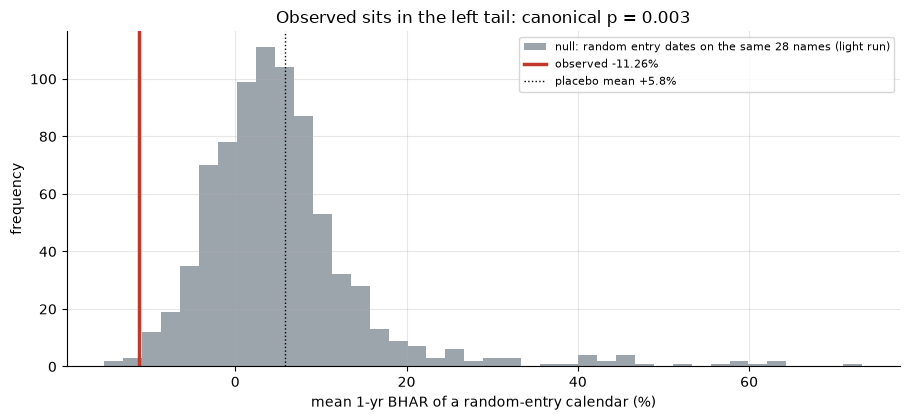

canonical placebo (results.md): mean +5.75%, sd 10.91%, p = 0.003


In [2]:
if HAVE_REAL:
    cs = st.car_stats(SPY, PRICES, TRADABLE, window=252)
    print(f"1-yr mean BHAR {cs['mean']*100:+.2f}%  one-sample t = {cs['t']:+.3f}"
          f"  (NW t = {cs['t_nw']:+.3f}, n={cs['n']})")
    wlo, whi = cs['wilson']
    print(f"hit rate (sponsor < SPY): {cs['hit']}/{cs['n']} = "
          f"{cs['hit_rate']*100:.1f}%  (Wilson [{wlo*100:.1f}%, {whi*100:.1f}%])")
    pl = st.placebo_pvalue(SPY, PRICES, TRADABLE, window=252, n_draws=800, seed=845)
    obs, draws = pl['obs'], pl['draws']
else:
    obs = R['w1_mean'] / 100
    rng = np.random.default_rng(845)
    draws = rng.normal(R['w1_pl_mean']/100, R['w1_pl_sd']/100, 800)
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.hist(draws * 100, bins=40, color=GREY, alpha=.85,
        label='null: random entry dates on the same 28 names (light run)')
ax.axvline(obs * 100, c=RED, lw=2.5, label=f'observed {obs*100:+.2f}%')
ax.axvline(R['w1_pl_mean'], c='k', ls=':', lw=1, label=f"placebo mean {R['w1_pl_mean']:+.1f}%")
ax.set_xlabel('mean 1-yr BHAR of a random-entry calendar (%)')
ax.set_ylabel('frequency')
ax.set_title(f"Observed sits in the left tail: canonical p = {R['w1_pl_p']:.3f}")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print(f"canonical placebo (results.md): mean {R['w1_pl_mean']:+.2f}%, "
      f"sd {R['w1_pl_sd']:.2f}%, p = {R['w1_pl_p']:.3f}")

> 💡 In plain words: the observed **-11.3%** sits in the left tail of a null whose *mean is positive* (**+5.8%** — these large-cap survivors normally beat SPY at a random entry), so a random calendar produces a drop this large only **0.3%** of the time. With one-sample t = **-2.54**, NW t = **-2.41** and a 75% hit rate, H₁ clears the |t| ≥ 2 bar on its own. Now the robustness that decides Weak vs Real.

### 4b · Horizon robustness — H₂, part 1

Repeat at the 2-year window. A real hubris effect should, if anything, *compound*; a crisis-timing artifact should wash out as the crisis passes.

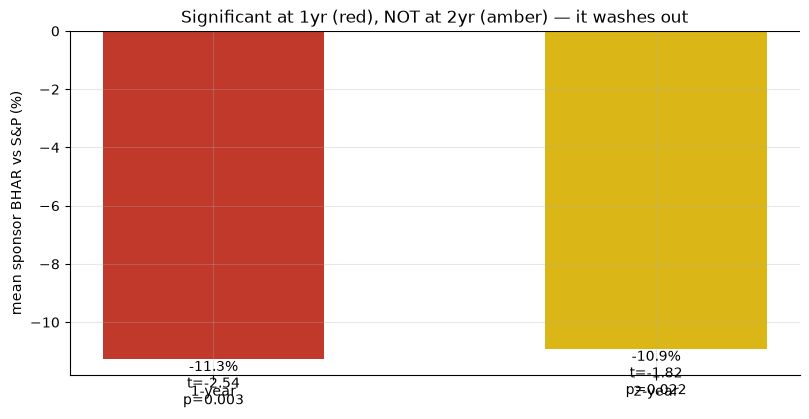

1yr t = -2.54 | 2yr t = -1.82


In [3]:
windows = [('1-year', 252), ('2-year', 504)]
means, ts, ps = [], [], []
for label, W in windows:
    if HAVE_REAL:
        cs = st.car_stats(SPY, PRICES, TRADABLE, window=W)
        means.append(cs['mean']*100); ts.append(cs['t'])
    else:
        means.append(R['w1_mean'] if W==252 else R['w2_mean'])
        ts.append(R['w1_t'] if W==252 else R['w2_t'])
    ps.append(R['w1_pl_p'] if W==252 else R['w2_pl_p'])
fig, ax = plt.subplots(figsize=(8.2, 4.3))
bars = ax.bar([w[0] for w in windows], means,
              color=[RED if abs(t)>=2 else AMBER for t in ts], width=.5)
for i, (m, t, p) in enumerate(zip(means, ts, ps)):
    ax.annotate(f'{m:+.1f}%\nt={t:+.2f}\np={p:.3f}', (i, m), ha='center', va='top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean sponsor BHAR vs S&P (%)')
ax.set_title('Significant at 1yr (red), NOT at 2yr (amber) — it washes out')
plt.tight_layout(); plt.show()
print('1yr t =', round(ts[0],2), '| 2yr t =', round(ts[1],2))

> 💡 In plain words: at 2 years the effect is **-10.9%** but t = **-1.82** — below the bar. It does not compound; it fades. That is the first crack in H₂ (a genuine hubris-driven derating of an over-investing firm would not politely reverse within the second year).

### 4c · Sub-era split & tail jackknife — H₂ part 2 and H₃, the demotion

The two cuts that separate Weak from Real: does it hold **before and after 2010**, and does it survive removing the worst couple of names?

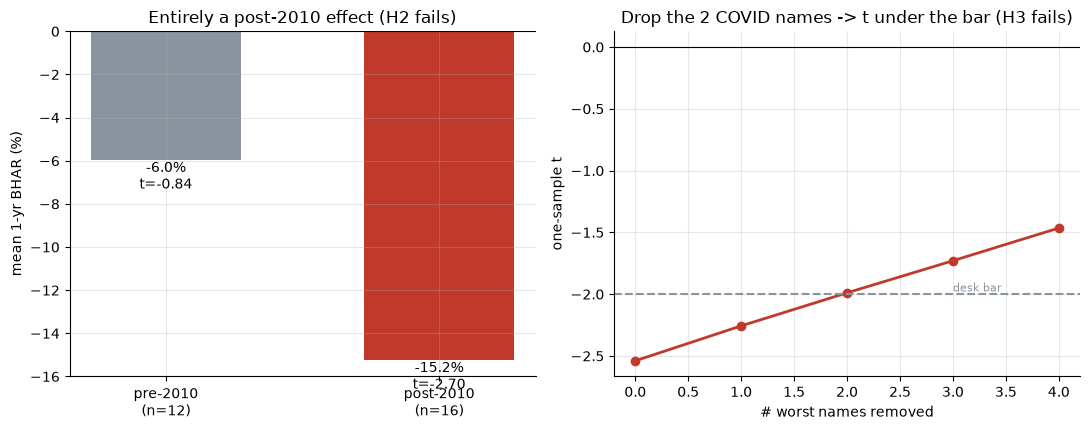

pre/post-2010 t: -0.84 -2.7
t dropping 0..4 worst: [-2.54, -2.26, -1.99, -1.73, -1.46]
leave-one-out t range: (-3.12, -2.26)


In [4]:
if HAVE_REAL:
    es = st.era_split(SPY, PRICES, TRADABLE, window=252)
    em = [es['pre']['mean']*100, es['post']['mean']*100]
    et = [es['pre']['t'], es['post']['t']]
    _, kept = st.stack_bhar(SPY, PRICES, TRADABLE, window=252)
    bs = np.sort(kept['bhar'].to_numpy())
    ks = list(range(5)); dt = []
    for k in ks:
        _, t = st.one_sample_t(bs[k:]); dt.append(t)
else:
    em = [R['w1_pre_mean'], R['w1_post_mean']]; et = [R['w1_pre_t'], R['w1_post_t']]
    ks = sorted(R['dropworst']); dt = [R['dropworst'][k][1] for k in ks]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.4))
a1.bar(['pre-2010\n(n=12)', 'post-2010\n(n=16)'], em, color=[GREY, RED], width=.55)
for i, (v, t) in enumerate(zip(em, et)):
    a1.annotate(f'{v:+.1f}%\nt={t:+.2f}', (i, v), ha='center', va='top')
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('mean 1-yr BHAR (%)')
a1.set_title('Entirely a post-2010 effect (H2 fails)')
a2.plot(ks, dt, 'o-', color=RED, lw=2)
a2.axhline(-2, ls='--', c=GREY); a2.axhline(0, c='k', lw=.8)
a2.annotate('desk bar', (3, -2), va='bottom', color=GREY, fontsize=8)
a2.set_xlabel('# worst names removed'); a2.set_ylabel('one-sample t')
a2.set_title('Drop the 2 COVID names -> t under the bar (H3 fails)')
plt.tight_layout(); plt.show()
print('pre/post-2010 t:', round(et[0],2), round(et[1],2))
print('t dropping 0..4 worst:', [round(x,2) for x in dt])
print('leave-one-out t range:', R['loo'])

> 💡 In plain words: **pre-2010 t = -0.84** (nothing) vs **post-2010 t = -2.70** — the whole effect is one era. And the tail jackknife: removing the two worst names (Caesars, Allegiant — both COVID casualties) takes t from -2.54 to **-1.99**, under the bar. Leave-one-out t stays in [-3.12, -2.26] (no *single* name flips it), but a law that dies on removing two names in one decade is **Weak**, not Real. Six of the sixteen post-2010 deals cluster in 2019–2021, right before COVID — hubris and crisis-timing luck are not separable at n=28.

### 4d · The tradable overlay — H₄, a costed short

Short the sponsor, long SPY for the window; 2 legs × one-way cost × NAV on entry+exit + borrow on the short. If the curse is real, this earns +BHAR.

window   gross %     net %   t(net)     win %
1-year 11.264051 10.064051 2.268639 71.428571
2-year 10.914504  8.714504 1.450853 60.714286


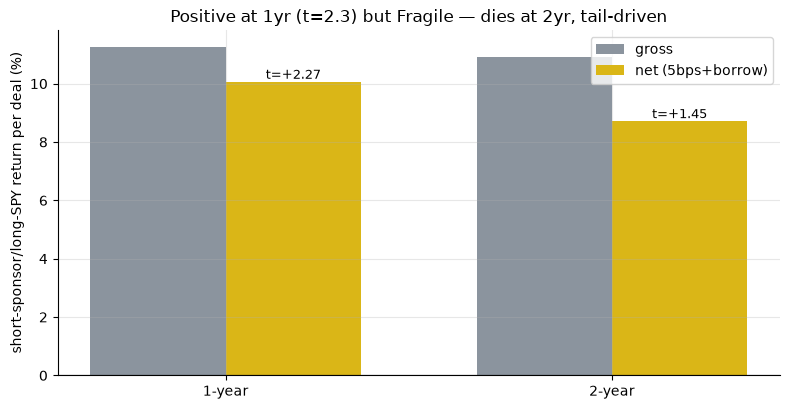

In [5]:
rows = []
for label, W in [('1-year', 252), ('2-year', 504)]:
    if HAVE_REAL:
        ov = st.curse_overlay(SPY, PRICES, TRADABLE, window=W,
                              cost_bps=5.0, borrow_bps_yr=100.0)
        rows.append((label, ov['gross_mean']*100, ov['net_mean']*100,
                     ov['t_net'], ov['win_rate']*100))
    else:
        if W == 252:
            rows.append((label, R['w1_ov_gross'], R['w1_ov_net'], R['w1_ov_t'], R['w1_ov_win']))
        else:
            rows.append((label, R['w2_ov_gross'], R['w2_ov_net'], R['w2_ov_t'], R['w2_ov_win']))
import pandas as pd
df = pd.DataFrame(rows, columns=['window', 'gross %', 'net %', 't(net)', 'win %'])
print(df.to_string(index=False))
fig, ax = plt.subplots(figsize=(8, 4.2))
x = np.arange(len(rows)); w = .35
ax.bar(x - w/2, [r[1] for r in rows], w, color=GREY, label='gross')
ax.bar(x + w/2, [r[2] for r in rows], w, color=AMBER, label='net (5bps+borrow)')
for i, r in enumerate(rows):
    ax.annotate(f't={r[3]:+.2f}', (i + w/2, r[2]), ha='center', va='bottom', fontsize=9)
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels([r[0] for r in rows])
ax.set_ylabel('short-sponsor/long-SPY return per deal (%)')
ax.set_title('Positive at 1yr (t=2.3) but Fragile — dies at 2yr, tail-driven')
ax.legend(); plt.tight_layout(); plt.show()

> 💡 In plain words: the 1-year short nets **+10.1%** per deal (t = 2.27) and survives costs — but it *is* the same fragile 1-year signal, it dies at 2 years (t = 1.45), and its payoff comes from shorting exactly the names that are hardest and priciest to borrow (Caesars, crypto-adjacent, high-short-interest) in exactly the crises that pay it. Real borrow on those dwarfs the 100 bps/yr charged here. With ~1 independent bet per year, H₄ is **Fragile**, not investable.

### 4e · Faithful-engine & power control — we know the truth here

Synthetic sponsor+SPY tapes with a TUNABLE planted post-deal drift, martingale-corrected so the null BHAR is mean-zero. The null (edge=0) is checked over **20 seeds** — never a single stream.

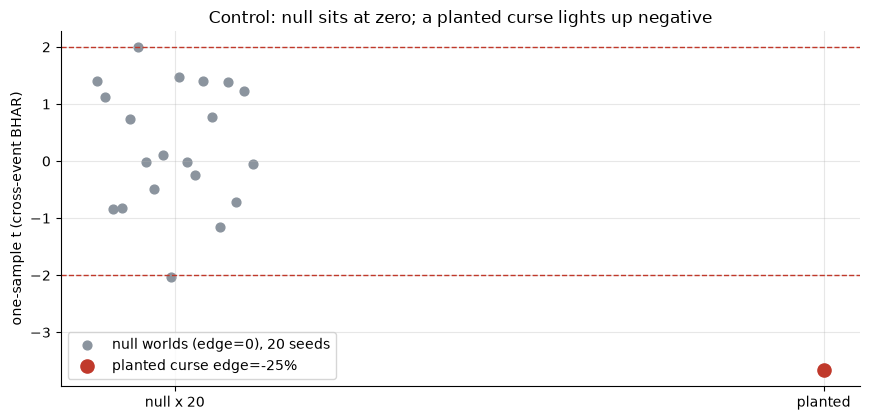

null: mean t = +0.26 (sd 1.08), |t|>=2 in 1/20  |  planted t = -3.66


In [6]:
null_ts = []
for s_ in range(20):
    spy_s, pr_s, ev_s = data.synthetic_world(edge=0.0, seed=845 + s_)
    null_ts.append(st.synthetic_detect(spy_s, pr_s, ev_s, window=252)['t'])
null_ts = np.asarray(null_ts)
spy_s, pr_s, ev_s = data.synthetic_world(edge=-0.25, seed=845)
planted_t = st.synthetic_detect(spy_s, pr_s, ev_s, window=252)['t']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.linspace(-.12, .12, 20), null_ts, color=GREY, s=40,
           label='null worlds (edge=0), 20 seeds')
ax.scatter([1], [planted_t], color=RED, s=90, zorder=5, label='planted curse edge=-25%')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 20', 'planted'])
ax.set_ylabel('one-sample t (cross-event BHAR)')
ax.set_title('Control: null sits at zero; a planted curse lights up negative')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(np.abs(null_ts)>=2).sum()}/20  |  planted t = {planted_t:+.2f}')

> 💡 In plain words: across 20 null worlds the detector averages t = +0.26 (sd 1.08) and crosses the bar 1/20 (~the 5% you'd expect); a planted −25% curse reads t = -3.66, correctly negative. The machinery is unbiased — the real-tape t = −2.54 is a genuine reading, and its **failure** of the robustness cuts is equally genuine. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `WEAK`** — 1-yr sponsor BHAR **-11.3%**, one-sample t = **-2.54** (NW -2.41), hit 75% (Wilson [56.6%, 87.3%]), placebo p = **0.003**. Real and correctly signed — more than the Enron/FTX cherry-pick — but it **fails every Real gate**: 2-yr t = -1.82, pre-2010 t = -0.84, drop-2-names t = -1.99. n=28, survivorship-trimmed, a 2019–2021 crisis cluster.
- **Tradability `FRAGILE`** — short-sponsor/long-SPY nets **+10.1%**/yr (t = 2.27) but dies at 2yr (t = 1.45), rides the same tail, and needs to short the least-borrowable names in a crisis. ~1 bet/year.
- **"Is the naming-rights curse real?" `MIXED`** — genuinely more than the anecdote (even survivors lag, placebo-significant) but not the robust law the legend implies: one era, a fat left tail of crisis-timed cyclicals, on a sample that already excludes the very bankruptcies (Enron, WorldCom) that started it.

## 6 · Going further

- **Identification is the honest limit.** With n=28 and a 2019–2021 cluster that ran into COVID, "hubris predicts underperformance" and "cyclical sponsors signed pre-crisis" are observationally equivalent here. A matched control (same-sector, same-size non-sponsors) and many more cycles would be the real test.
- **Survivorship makes this finding *conservative*.** Because the actual bankruptcies are excluded, a true curse would be worse than −11% — a rare case where the bias understates rather than inflates.
- **Dedup map:** [160-skyscraper-curse](../../160-skyscraper-curse/) (a *building*, macro-timing), [746-hq-relocation](../../746-hq-relocation/) (a *capex/HQ* move) and [722-logo-rebrand](../../722-logo-rebrand/) (a *rebrand* of the firm's own identity) — same corporate-vanity family, different trophies and event sets.

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*